*Importing the needed libraries:*

In [ ]:
import os
import math
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
from tqdm.notebook import tqdm

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test, multivariate_logrank_test

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table
import matplotlib.transforms as mtransforms

import scipy.stats
from scipy.stats import norm, zscore, fisher_exact, chi2_contingency, mannwhitneyu

*Setting the parameters for AI-friendly export format of the plots:*

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the main dataframe with clinical metadata and flow cytometry parameters:*

In [ ]:
# upper day limit for horizoning the clinical follow-up
cutoff = 2000

print('reading the main dataframe:')
# path to the full dataset excel with clinical metadata and flow cytometry parameters for the patients:
full_dataset_clinmetadata_flowcytometrydata_path = ''
d35_input_full = pd.read_excel(full_dataset_clinmetadata_flowcytometrydata_path)
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['RFS']['time']])

d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['OS']['time']])

d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])

d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])


d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)


d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']


df_multivariate = d35_input_full_copy.copy()
age_cutoff = 60
df_multivariate[f'Age(>{age_cutoff})'] = np.where(df_multivariate['Age'] > age_cutoff, 1, 0)
df_multivariate['MHC_Mismatch_between_Donor&Recipient'] = np.where(df_multivariate['MHC_Mismatch_between_Donor&Recipient'] == 'nein', 'Match', 'Mismatch')
df_multivariate['MHC_Mismatch_Numeric'] = np.where(df_multivariate['HLA_Category_refined'] != '10/10', 'Mismatch', '10/10')
df_multivariate['ELN_Score(3)'] = np.where(df_multivariate['ELN_Score'] == 3, 1, 0)
d35_input_full_copy['Sex_Recipient(M=1)'] = np.where(d35_input_full_copy['Sex_Recipient'] == 'Male', 1, 0) # Male = 0, Female = 1

df_multivariate['Disease_Score(2)'] = np.where(df_multivariate['Disease_Score'] == 2, 1, 0)
df_multivariate['CMV_Status_Recipient(+)'] = np.where(df_multivariate['CMV_Status_Recipient'] == 'neg', "CMV R neg", "CMV R pos")
df_multivariate['CMV_Status(R/D)'] = df_multivariate['CMV_Status_Recipient'] + '_' + df_multivariate['CMV_Status_Donor']

reading the main dataframe:


<br></br>
<br></br>
*Building boxplots for individual immune parameters:*

In [40]:
merged = False

cohort_selected = 'Cohort 2'
# 'Cohort 1' / 'Cohort 2'
split = '2cats'
# '2cats' or '4cats'

parameter_chosen = 'CD4 CCR7mid CD45RA- of T'
'CD4 CCR7mid CD45RA- of T'
'CD4_Naive+CD4_TCM-to-CD4_rest'
'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM'

ylabel_dict = {
    'CD4 CCR7mid CD45RA- of T': 'CD4 TCM of T',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'CD4 (Naive + TCM) to CD4 rest',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1 GPR56+ CD57+ of CD8 TEM',
}
filename_dict = {
    'CD4 CCR7mid CD45RA- of T': 'CD4TCMofT',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'CD4NVTCMratio',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8TEM++',    
    'CMV_Status(R/D)': 'CMVStatusRD',
    'MHC_Mismatch_Numeric': 'MHC_Mismatch',
}

FDR_corr = False
if FDR_corr:
    stat_add_on = '_FDR_corr'
else:
    stat_add_on = ''

clin_var_selected = 'MHC_Mismatch_Numeric'
# 'CMV_Status(R/D)' / 'MHC_Mismatch_Numeric'
x_label_dict = {
    'CMV_Status(R/D)': 'CMV status (Recipient / Donor)',
    'MHC_Mismatch_Numeric': 'MHC mismatch (Recipient / Donor)'
}

In [41]:
x = df_multivariate[[clin_var_selected,parameter_chosen, 'Cohort']].copy()
x['Cohort'] = x['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})
if merged:
    short_name = ""
    palette_selected = ["#9FC5E8", "#E06666"]
else:
    if cohort_selected == 'Cohort 1':
        short_name = '_C1'
        palette_selected = ["#9FC5E8"]
    else:
        short_name = '_C2'
        palette_selected = ["#E06666"]

if split == '4cats':
    if clin_var_selected == 'CMV_Status(R/D)':
        x['CMV_Status(R/D)'] = x['CMV_Status(R/D)'].replace({
            'pos_pos': '+/+',
            'neg_neg': '-/-',
            'pos_neg': '+/-',
            'neg_pos': '-/+'})
        specified_order = ['+/+', '+/-','-/+','-/-']

    specified_size = (7,5)
    groups = specified_order

    if merged:
        pairs = []
        for cohort in ["Cohort 1", "Cohort 2"]:
            for i in range(len(groups)):
                for j in range(i + 1, len(groups)):
                    pairs.append(
                        ((groups[i], cohort), (groups[j], cohort))
                    )
    else:
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append(
                    ((groups[i]), (groups[j]))
                )
else:
    if clin_var_selected == 'CMV_Status(R/D)':
        x['CMV_Status(R/D)'] = x['CMV_Status(R/D)'].replace({
            'pos_pos': '+/+',
            'neg_neg': 'Other',
            'pos_neg': 'Other',
            'neg_pos': 'Other'})
        specified_order = ['+/+','Other']
    elif clin_var_selected == 'MHC_Mismatch_Numeric':
        specified_order = ['10/10','Mismatch']

    specified_size = (5,4)

    if merged:
        if clin_var_selected == 'CMV_Status(R/D)':
            pairs = [
                (("+/+", "Cohort 1"), ("Other", "Cohort 1")),
                (("+/+", "Cohort 2"), ("Other", "Cohort 2")),
            ]
        elif clin_var_selected == 'MHC_Mismatch_Numeric':
            pairs = [
                (("10/10", "Cohort 1"), ("Mismatch", "Cohort 1")),
                (("10/10", "Cohort 2"), ("Mismatch", "Cohort 2")),
            ]
    else:
        if clin_var_selected == 'CMV_Status(R/D)':
            pairs = [(("+/+"), ("Other"))]
        else:
            pairs = [(("10/10"), ("Mismatch"))]

*Adding statistical annotations:*

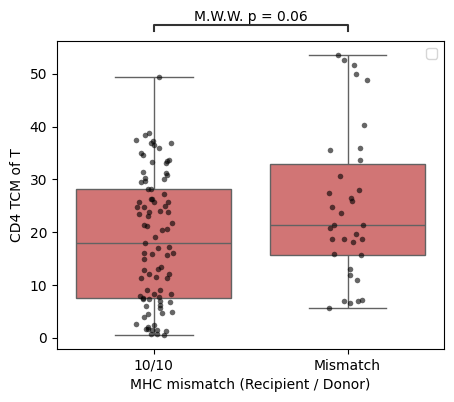

In [ ]:
from statannotations.Annotator import Annotator
from contextlib import redirect_stdout

if merged:
    x = x.copy()
else:
    x = x[x['Cohort'] == cohort_selected]
fig,ax = plt.subplots(figsize=specified_size)

if merged:
    sns.boxplot(
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        hue='Cohort',
        showfliers=False,
        palette=palette_selected,
        ax = ax,
        order = specified_order
    )
    sns.stripplot(
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        hue='Cohort',
        dodge=True,
        color='black',
        alpha=0.6,
        size=4, legend = False, 
        ax = ax,
        order = specified_order)
else:
    sns.boxplot(
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        showfliers=False,
        palette=palette_selected,
        ax = ax,
        order = specified_order
    )
    sns.stripplot(
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        dodge=True,
        color='black',
        alpha=0.6,
        size=4, legend = False, 
        ax = ax,
        order = specified_order)
saving_path_plot_no_stat_annotations = ''
plt.savefig(saving_path_plot_no_stat_annotations, bbox_inches = 'tight')

if merged:
    annotator = Annotator(
        ax,
        pairs,
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        order = specified_order,
        hue='Cohort'
    )
else:
    annotator = Annotator(
        ax,
        pairs,
        data=x,
        x=clin_var_selected,
        y=parameter_chosen,
        order = specified_order
    )   

saving_path_text_stat_annotations = ''
with open(saving_path_text_stat_annotations, "w") as f:
    with redirect_stdout(f):
        annotator.configure(
            test='Mann-Whitney',
            text_format='simple',
            loc='outside',
            comparisons_correction="BH" if FDR_corr else None,
            hide_non_significant=False,
            verbose=1
        )
        annotator.apply_and_annotate()

ax.legend(title='')
ax.set_xlabel(x_label_dict[clin_var_selected])
ax.set_ylabel(ylabel_dict[parameter_chosen])
saving_path_plot_with_stat_annotations = ''
plt.savefig(saving_path_plot_with_stat_annotations, bbox_inches = 'tight')
plt.show()

